In [1]:
import os
import time
import random
import numpy as np
import pandas as pd
import tensorflow as tf

In [2]:
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from tensorflow import keras
from tensorflow.keras import layers
from codecarbon import EmissionsTracker

In [4]:
seed = 42

random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [5]:
#load dataset
dataset = load_dataset("takala/financial_phrasebank", "sentences_allagree")

df = pd.DataFrame(dataset["train"])

print(df.head())
print(df["label"].value_counts())
print(df.isnull().sum())

                                            sentence  label
0  According to Gran , the company has no plans t...      1
1  For the last quarter of 2010 , Componenta 's n...      2
2  In the third quarter of 2010 , net sales incre...      2
3  Operating profit rose to EUR 13.1 mn from EUR ...      2
4  Operating profit totalled EUR 21.1 mn , up fro...      2
label
1    1391
2     570
0     303
Name: count, dtype: int64
sentence    0
label       0
dtype: int64


In [6]:
#split data 
X = df["sentence"].values
y = df["label"].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))

Train size: 1584
Validation size: 340
Test size: 340


In [7]:
#text vectorizaion
max_tokens = 10000
sequence_length = 40

vectorizer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

vectorizer.adapt(X_train)

2026-05-04 12:50:53.955579: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-05-04 12:50:53.955746: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-04 12:50:53.955764: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2026-05-04 12:50:53.956010: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 12:50:53.956040: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
#early stopping
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

In [9]:
class TimeHistory(keras.callbacks.Callback):

    def on_train_begin(self, logs=None):
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start_time = time.time()

    def on_epoch_end(self, epoch, logs=None):
        epoch_time = time.time() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

In [11]:
#helper function for evaluation
def evaluate_model(model, X_test, y_test, model_name):
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    y_pred_probs = model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)

    print(model_name)
    print("Test accuracy:", test_acc)
    print("Test loss:", test_loss)
    print()
    print(classification_report(y_test, y_pred))
    print()
    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    return test_loss, test_acc

In [12]:
#build simpleRNN 
tf.keras.backend.clear_session()
tf.random.set_seed(seed)

model_rnn = keras.Sequential([
    vectorizer,
    layers.Embedding(input_dim=max_tokens, output_dim=32),
    layers.SimpleRNN(32),
    layers.Dense(3, activation="softmax")
])

model_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
#simple RNN training modified 

tracker_rnn = EmissionsTracker(project_name="SimpleRNN_epoch_timing")

time_callback_rnn = TimeHistory()

start_time_rnn = time.time()
tracker_rnn.start()

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop, time_callback_rnn],
    verbose=1
)

emissions_rnn = tracker_rnn.stop()
end_time_rnn = time.time()

training_time_rnn = end_time_rnn - start_time_rnn

print("SimpleRNN emissions:", emissions_rnn)
print("Total training time:", training_time_rnn)
print("Epoch-by-epoch time:", time_callback_rnn.epoch_times)

[codecarbon WARNING @ 20:42:49] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 20:42:49] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 20:42:49] [setup] RAM Tracking...
[codecarbon INFO @ 20:42:49] [setup] CPU Tracking...
[codecarbon WARNING @ 20:42:49] We saw that you have a Apple M2 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 20:42:49] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 20:42:49] CPU Model on constant consumption mode: Apple M2 Pro
[codecarbon WARNING @ 20:42:49] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 20:42:49] [setup] GPU Tracking...
[codecarbon INFO @ 20:42:49] No GPU found.
[codecarbon INFO @ 20:42:49] The below tracking methods have been set up:
    

Epoch 1/5


2026-04-30 20:42:52.874840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/50 ━━━━━━━━━━━━━━━━━━━━ 20s 670ms/step - accuracy: 0.5667 - loss: 0.9693

[codecarbon INFO @ 20:43:07] Energy consumed for RAM : 0.000013 kWh. RAM Power : 3.0 W
[codecarbon INFO @ 20:43:07] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:43:07] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 20:43:07] 0.000190 kWh of electricity and 0.000000 L of water were used since the beginning.


...

41/50 ━━━━━━━━━━━━━━━━━━━━ 6s 669ms/step - accuracy: 0.8811 - loss: 0.4109

[codecarbon INFO @ 20:45:37] Energy consumed for RAM : 0.000137 kWh. RAM Power : 3.0 W
[codecarbon INFO @ 20:45:37] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 20:45:37] Energy consumed for All CPU : 0.001948 kWh
[codecarbon INFO @ 20:45:37] 0.002085 kWh of electricity and 0.000000 L of water were used since the beginning.


50/50 ━━━━━━━━━━━━━━━━━━━━ 34s 680ms/step - accuracy: 0.9015 - loss: 0.3403 - val_accuracy: 0.7412 - val_loss: 0.6594


[codecarbon INFO @ 20:45:44] Energy consumed for RAM : 0.000143 kWh. RAM Power : 3.0 W
[codecarbon INFO @ 20:45:44] Delta energy consumed for CPU with constant : 0.000078 kWh, power : 42.5 W
[codecarbon INFO @ 20:45:44] Energy consumed for All CPU : 0.002026 kWh
[codecarbon INFO @ 20:45:44] 0.002169 kWh of electricity and 0.000000 L of water were used since the beginning.


SimpleRNN emissions: 0.0009960946772506834
Total training time: 171.5979597568512
Epoch-by-epoch time: [35.14492583274841, 34.11648201942444, 34.178359031677246, 34.07598805427551, 34.01171088218689]


In [14]:
test_loss_rnn, test_acc_rnn = evaluate_model(
    model_rnn,
    X_test,
    y_test,
    "SimpleRNN"
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
SimpleRNN
Test accuracy: 0.7352941036224365
Test loss: 0.6677340269088745

              precision    recall  f1-score   support

           0       0.49      0.37      0.42        46
           1       0.86      0.90      0.88       209
           2       0.52      0.53      0.53        85

    accuracy                           0.74       340
   macro avg       0.62      0.60      0.61       340
weighted avg       0.72      0.74      0.73       340


Confusion matrix:
[[ 17   5  24]
 [  4 188  17]
 [ 14  26  45]]


In [15]:
#build LSTM

tf.keras.backend.clear_session()
tf.random.set_seed(seed)

model_lstm = keras.Sequential([
    vectorizer,
    layers.Embedding(input_dim=max_tokens, output_dim=32),
    layers.LSTM(32),
    layers.Dense(3, activation="softmax")
])

model_lstm.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization              │ (None, 40)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
#train LSTM with code carbon modified

tracker_lstm = EmissionsTracker(project_name="LSTM_epoch_timing")

time_callback_lstm = TimeHistory()

start_time_lstm = time.time()
tracker_lstm.start()

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop, time_callback_lstm],
    verbose=1
)

emissions_lstm = tracker_lstm.stop()
end_time_lstm = time.time()

training_time_lstm = end_time_lstm - start_time_lstm

print("LSTM emissions:", emissions_lstm)
print("Total training time:", training_time_lstm)
print("Epoch-by-epoch time:", time_callback_lstm.epoch_times)

[codecarbon WARNING @ 20:48:00] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 20:48:00] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 20:48:00] [setup] RAM Tracking...
[codecarbon INFO @ 20:48:00] [setup] CPU Tracking...
[codecarbon WARNING @ 20:48:00] We saw that you have a Apple M2 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 20:48:00] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 20:48:00] CPU Model on constant consumption mode: Apple M2 Pro
[codecarbon WARNING @ 20:48:00] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 20:48:00] [setup] GPU Tracking...
[codecarbon INFO @ 20:48:00] No GPU found.
[codecarbon INFO @ 20:48:00] The below tracking methods have been set up:
    

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6168 - loss: 0.9346 - val_accuracy: 0.6147 - val_loss: 0.8924
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6856 - loss: 0.7503 - val_accuracy: 0.7559 - val_loss: 0.5827
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8005 - loss: 0.4893 - val_accuracy: 0.7235 - val_loss: 0.6216
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8321 - loss: 0.3798 - val_accuracy: 0.7853 - val_loss: 0.6352


[codecarbon INFO @ 20:48:05] Energy consumed for RAM : 0.000003 kWh. RAM Power : 3.0 W
[codecarbon INFO @ 20:48:05] Delta energy consumed for CPU with constant : 0.000037 kWh, power : 42.5 W
[codecarbon INFO @ 20:48:05] Energy consumed for All CPU : 0.000037 kWh
[codecarbon INFO @ 20:48:05] 0.000040 kWh of electricity and 0.000000 L of water were used since the beginning.


LSTM emissions: 1.8225670172266358e-05
Total training time: 3.144589900970459
Epoch-by-epoch time: [1.4385240077972412, 0.5373978614807129, 0.5565547943115234, 0.5490908622741699]


In [17]:
test_loss_lstm, test_acc_lstm = evaluate_model(
    model_lstm,
    X_test,
    y_test,
    "LSTM"
)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
LSTM
Test accuracy: 0.7352941036224365
Test loss: 0.6393872499465942

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        46
           1       0.87      0.90      0.88       209
           2       0.50      0.73      0.60        85

    accuracy                           0.74       340
   macro avg       0.46      0.54      0.49       340
weighted avg       0.66      0.74      0.69       340


Confusion matrix:
[[  0   6  40]
 [  0 188  21]
 [  0  23  62]]


/Users/ariellecameron/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ariellecameron/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ariellecameron/tf_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [16]:
comparison_df = pd.DataFrame({
    "Model": ["SimpleRNN", "LSTM"],
    "Test Accuracy": [test_acc_rnn, test_acc_lstm],
    "Test Loss": [test_loss_rnn, test_loss_lstm],
    "Training Time (seconds)": [training_time_rnn, training_time_lstm],
    "Epochs Completed": [
        len(history_rnn.history["loss"]),
        len(history_lstm.history["loss"])
    ],
    "Emissions (kg CO2)": [emissions_rnn, emissions_lstm],
    "Parameters": [
        model_rnn.count_params(),
        model_lstm.count_params()
    ]
})

comparison_df

,Model,Test Accuracy,Test Loss,Training Time (seconds),Epochs Completed,Emissions (kg CO2),Parameters
0,SimpleRNN,0.688235,0.770461,173.368859,5,0.001006,322179
1,LSTM,0.735294,0.639387,3.355713,4,0.000019,328419


In [17]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Physical devices:", tf.config.list_physical_devices())
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("CPU devices:", tf.config.list_physical_devices("CPU"))

TensorFlow version: 2.16.2
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [10]:
def train_model_with_emissions(model, model_name):
    tracker = EmissionsTracker(project_name=model_name)
    time_callback = TimeHistory()

    start_time = time.time()
    tracker.start()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=32,
        callbacks=[early_stop, time_callback],
        verbose=1
    )

    emissions = tracker.stop()
    end_time = time.time()

    training_time = end_time - start_time
    avg_epoch_time = np.mean(time_callback.epoch_times)

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(model_name)
    print("Test accuracy:", test_acc)
    print("Test loss:", test_loss)
    print("Training time:", training_time)
    print("Average epoch time:", avg_epoch_time)
    print("Emissions:", emissions)
    print("Parameters:", model.count_params())

    return {
        "Model": model_name,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss,
        "Training Time (seconds)": training_time,
        "Average Epoch Time (seconds)": avg_epoch_time,
        "Epochs Completed": len(history.history["loss"]),
        "Emissions (kg CO2)": emissions,
        "Parameters": model.count_params()
    }

In [11]:
def build_recurrent_model(model_type, units):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)

    if model_type == "SimpleRNN":
        recurrent_layer = layers.SimpleRNN(units)
    elif model_type == "LSTM":
        recurrent_layer = layers.LSTM(units)
    else:
        raise ValueError("model_type must be 'SimpleRNN' or 'LSTM'")

    model = keras.Sequential([
        vectorizer,
        layers.Embedding(input_dim=max_tokens, output_dim=32),
        recurrent_layer,
        layers.Dense(3, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
results = []

model_rnn_16 = build_recurrent_model("SimpleRNN", 16)
results.append(train_model_with_emissions(model_rnn_16, "SimpleRNN(16)"))

model_lstm_16 = build_recurrent_model("LSTM", 16)
results.append(train_model_with_emissions(model_lstm_16, "LSTM(16)"))

model_rnn_32 = build_recurrent_model("SimpleRNN", 32)
results.append(train_model_with_emissions(model_rnn_32, "SimpleRNN(32)"))

model_lstm_32 = build_recurrent_model("LSTM", 32)
results.append(train_model_with_emissions(model_lstm_32, "LSTM(32)"))

[codecarbon WARNING @ 12:52:46] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 12:52:46] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon INFO @ 12:52:46] [setup] RAM Tracking...
[codecarbon INFO @ 12:52:46] [setup] CPU Tracking...
[codecarbon WARNING @ 12:52:46] We saw that you have a Apple M2 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 12:52:46] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon INFO @ 12:52:46] CPU Model on constant consumption mode: Apple M2 Pro
[codecarbon WARNING @ 12:52:46] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 12:52:46] [setup] GPU Tracking...
[codecarbon INFO @ 12:52:46] No GPU found.
[codecarbon INFO @ 12:52:46] The below tracking methods have been set up:
    

Epoch 1/5


2026-05-04 12:52:49.775852: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


20/50 ━━━━━━━━━━━━━━━━━━━━ 20s 673ms/step - accuracy: 0.6054 - loss: 0.9693

[codecarbon INFO @ 12:53:04] Energy consumed for RAM : 0.000013 kWh. RAM Power : 3.0 W
[codecarbon INFO @ 12:53:04] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 12:53:04] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 12:53:04] 0.000190 kWh of electricity and 0.000000 L of water were used since the beginning.


...

SimpleRNN(32)
Test accuracy: 0.729411780834198
Test loss: 0.6946777105331421
Training time: 69.32535791397095
Average epoch time: 34.642488956451416
Emissions: 0.0004024166714462971
Parameters: 322179


[codecarbon INFO @ 12:57:00] Emissions data (if any) will be saved to file /Users/ariellecameron/emissions.csv


Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6080 - loss: 0.9358 - val_accuracy: 0.6147 - val_loss: 0.8991
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6294 - loss: 0.8869 - val_accuracy: 0.6765 - val_loss: 0.7438


[codecarbon INFO @ 12:57:02] Energy consumed for RAM : 0.000002 kWh. RAM Power : 3.0 W
[codecarbon INFO @ 12:57:02] Delta energy consumed for CPU with constant : 0.000024 kWh, power : 42.5 W
[codecarbon INFO @ 12:57:02] Energy consumed for All CPU : 0.000024 kWh
[codecarbon INFO @ 12:57:02] 0.000026 kWh of electricity and 0.000000 L of water were used since the beginning.


LSTM(32)
Test accuracy: 0.6235294342041016
Test loss: 0.8993827104568481
Training time: 2.062854051589966
Average epoch time: 0.9933255910873413
Emissions: 1.19393311236191e-05
Parameters: 328419


In [13]:
final_comparison_df = pd.DataFrame(results)
final_comparison_df

,Model,Test Accuracy,Test Loss,Training Time (seconds),Average Epoch Time (seconds),Epochs Completed,Emissions (kg CO2),Parameters
0,SimpleRNN(16),0.750000,0.582956,172.546978,34.497667,5,0.001002,320835
1,LSTM(16),0.626471,0.905187,2.232980,1.081454,2,0.000013,323187
2,SimpleRNN(32),0.729412,0.694678,69.325358,34.642489,2,0.000402,322179
3,LSTM(32),0.623529,0.899383,2.062854,0.993326,2,0.000012,328419


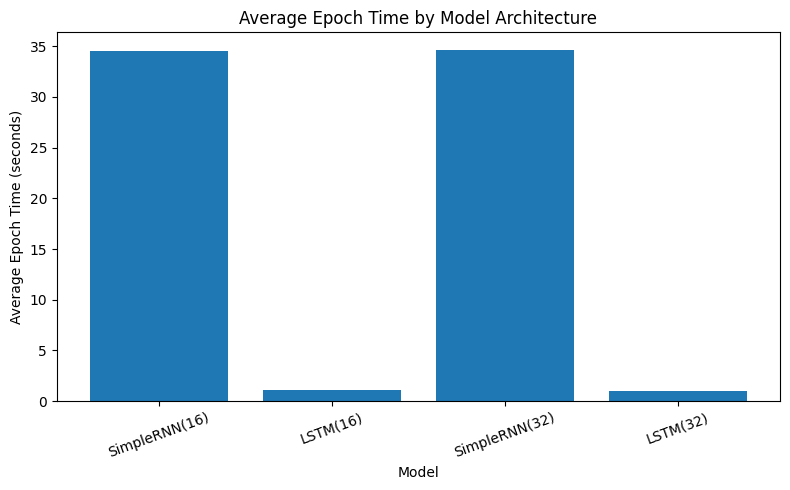

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    final_comparison_df["Model"],
    final_comparison_df["Average Epoch Time (seconds)"]
)

plt.xlabel("Model")
plt.ylabel("Average Epoch Time (seconds)")
plt.title("Average Epoch Time by Model Architecture")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()